In [9]:
import numpy as np
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 3))
R_store=[]
Energy_store=[]
X_store=[]
for files in [51,75,85,100,120,140,160,180,200]: 
    h_sub=np.loadtxt(f'h_{files}.txt')
    theta = np.linspace(0, 2 * np.pi, len(h_sub[0]), endpoint=False)


    dt=2e-4
    
    ti=0
    
    tf=6000
   
    Tf_units=tf*dt
    Ti_units=ti*dt
        
    u=np.array(h_sub).T[:,ti:tf]
    t=np.arange(Ti_units,Tf_units,dt)
    print("lent",len(t))
    
    tot_t_len=len(u[0])
    
    U, S,Vt = np.linalg.svd(u)
    #ip=inner_product(u,thetas)
    #modes,feature_names, S2, Vh=vector_POD(ip,t,4)
    
    ri = 10
    Ur = U[:, :ri]
    Sr = np.diag(S[:ri])
    modes= Vt[:ri, :7000]
    
   
    R_store.append(modes)
    Energy_store.append(Sr)
    X_store.append(Ur)
   
    


lent 6000
lent 6000
lent 6000
lent 6000
lent 6000
lent 6000
lent 6000
lent 6000
lent 6000


<Figure size 720x216 with 0 Axes>


Statistics for each distribution:

Mode q_1:
  Λ= 75: mean =   0.0003, variance =   0.0002, kurtosis =   1.3736, skewness =   0.2502
  Λ= 85: mean =  -0.0001, variance =   0.0002, kurtosis =   2.8752, skewness =   0.2818
  Λ=100: mean =   0.0000, variance =   0.0002, kurtosis =   3.9868, skewness =   0.2543
  Λ=120: mean =  -0.0002, variance =   0.0002, kurtosis =   2.5541, skewness =  -0.1482
  Λ=140: mean =   0.0000, variance =   0.0002, kurtosis =   2.8739, skewness =   0.2816
  Λ=160: mean =  -0.0002, variance =   0.0002, kurtosis =   1.5082, skewness =  -0.0473
  Λ=180: mean =   0.0000, variance =   0.0002, kurtosis =   3.9877, skewness =   0.2545
  Λ=200: mean =   0.0002, variance =   0.0002, kurtosis =   2.9829, skewness =   0.2055

Mode q_2:
  Λ= 75: mean =   0.0002, variance =   0.0002, kurtosis =   2.2065, skewness =  -0.2671
  Λ= 85: mean =  -0.0002, variance =   0.0002, kurtosis =   1.7299, skewness =  -0.0362
  Λ=100: mean =  -0.0002, variance =   0.0002, kurtosis =   6.4

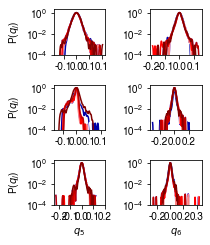

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kurtosis, skew
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

R_store = np.array(R_store)

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Create figure with 6 subplots (3 rows, 2 columns) - more compact
fig, axes = plt.subplots(3, 2, figsize=(3., 3.5))
fig.subplots_adjust(hspace=0.25, wspace=0.25)  # Reduced spacing
labels = [50,75,85, 100, 120,140, 160, 180,200]

print("\nStatistics for each distribution:")
print("=" * 80)
kurtosis_list=[]
skewness_list=[]
for n in range(6):
    # Convert linear index to 2D indices for 3 rows, 2 columns
    row = n // 2
    col = n % 2
    ax = axes[row, col]
    
    all_vals = np.concatenate(R_store[:, n, :])
    x_vals = np.linspace(np.min(all_vals), np.max(all_vals), 200)
    
    cmap = cm.get_cmap('seismic', len(R_store[:, n, :]))
    
    print(f"\nMode q_{n+1}:")

    kurtosis_mode=[]
    skewness_mode=[]
    for i, R_f in enumerate(R_store[:, n, :]):
        kde = gaussian_kde(R_f)
        y = kde(x_vals)
        
        # Normalize KDE to have max value of 1
        y_norm = y / np.max(y)
        
        if i>0:
            ax.plot(x_vals, y_norm, color=cmap(i), label=labels[i], linewidth=1.5)
        
        # Calculate statistics
        mean_val = np.mean(R_f)
        var_val = np.var(R_f)
        kurt = kurtosis(R_f, fisher=True)  # fisher=True gives excess kurtosis
        skewness = skew(R_f)
        
        if i>0:
            print(f"  Λ={labels[i]:3d}: mean = {mean_val:8.4f}, variance = {var_val:8.4f}, kurtosis = {kurt:8.4f}, skewness = {skewness:8.4f}")
            kurtosis_mode.append(kurt)
            skewness_mode.append(skewness)
    kurtosis_list.append(kurtosis_mode)
    skewness_list.append(skewness_mode)

    # X-label on bottom row only
    if row == 2:
        ax.set_xlabel(f'$q_{{{n+1}}}$', fontproperties=helvetica, fontsize=10)
    
    # Y-label on left column only
    if col == 0:
        ax.set_ylabel('P($q_j$)', fontproperties=helvetica, fontsize=10)
    
    ax.set_yscale('log')
    ax.set_ylim([0.0001, 2])  # Adjusted for normalized values
    
    # Format x-axis to show 1 decimal place
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Ensure ticks include both negative and positive values
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, symmetric=True))
    
    # Reduce tick label size for compactness
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Only show legend on the last subplot (bottom right)
    #if n == 5:
        #ax.legend(title=r'$\Lambda$', prop=helvetica, fontsize=6, loc='best')
    
    # Apply Helvetica to tick labels
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

print("=" * 80)
plt.tight_layout()
plt.savefig("mode_hist/AAmodes_all_subplots.png", bbox_inches='tight', dpi=500)
plt.show()

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


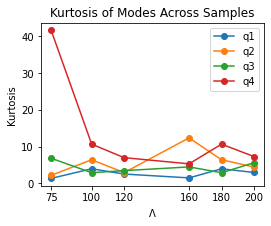

In [3]:
labels = [75, 100, 120, 160, 180, 200]
plt.figure(figsize=(4, 3))
for i in range(4):
    kurtosis = kurtosis_list[i]
    plt.plot(labels, kurtosis, marker='o', label=f'q{i+1}')
plt.xticks(labels)
plt.xlabel('$\Lambda$')
plt.ylabel('Kurtosis')
plt.title('Kurtosis of Modes Across Samples')
plt.legend()
plt.savefig("mode_hist/kurtosis_modes.png", bbox_inches='tight', dpi=500)

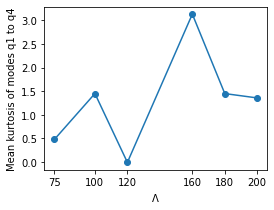

In [6]:
## sum lists vertically
kurtosis_array = np.array(kurtosis_list)
mean_kurtosis = np.mean(kurtosis_array[:3,:], axis=0)
  
plt.figure(figsize=(4, 3))
labels = [75, 100, 120, 160, 180, 200   ]
plt.errorbar(labels, mean_kurtosis-3, fmt='o-', capsize=5)
plt.xticks(labels)
plt.xlabel('$\Lambda$')
plt.ylabel('Mean kurtosis of modes q1 to q4')
plt.savefig("mode_hist/mean_kurtosis_modes.png", bbox_inches='tight', dpi=500)
np.savetxt("mode_hist/mean_kurtosis_modes.txt", np.column_stack((labels, mean_kurtosis-3)), header="Lambda Mean_Kurtosis")
plt.show()

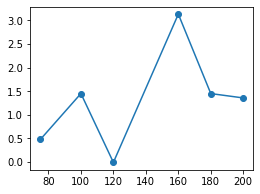

In [8]:
mean_kurtosis = np.loadtxt("mode_hist/mean_kurtosis_modes.txt", skiprows=1)
labels = mean_kurtosis[:,0]
mean_kurtosis = mean_kurtosis[:,1]
plt.figure(figsize=(4, 3))
plt.plot(labels, mean_kurtosis, marker='o')


Kurtosis values for each distribution:

Mode q_1:
  Λ= 75: kurtosis =   1.3736
  Λ=100: kurtosis =   3.9868
  Λ=120: kurtosis =   2.5541
  Λ=160: kurtosis =   1.5082
  Λ=180: kurtosis =   3.9876
  Λ=200: kurtosis =   2.9829

Mode q_2:
  Λ= 75: kurtosis =   2.2065
  Λ=100: kurtosis =   6.4411
  Λ=120: kurtosis =   2.9404
  Λ=160: kurtosis =  12.3910
  Λ=180: kurtosis =   6.4385
  Λ=200: kurtosis =   4.4582

Mode q_3:
  Λ= 75: kurtosis =   6.8488
  Λ=100: kurtosis =   2.9199
  Λ=120: kurtosis =   3.4798
  Λ=160: kurtosis =   4.4945
  Λ=180: kurtosis =   2.9199
  Λ=200: kurtosis =   5.6280

Mode q_4:
  Λ= 75: kurtosis =  41.6998
  Λ=100: kurtosis =  10.6831
  Λ=120: kurtosis =   7.0103
  Λ=160: kurtosis =   5.3341
  Λ=180: kurtosis =  10.6868
  Λ=200: kurtosis =   7.3097

Mode q_5:
  Λ= 75: kurtosis =   5.3445
  Λ=100: kurtosis =  26.4595
  Λ=120: kurtosis =  15.0953
  Λ=160: kurtosis =  12.4062
  Λ=180: kurtosis =  26.4587
  Λ=200: kurtosis =   9.3474


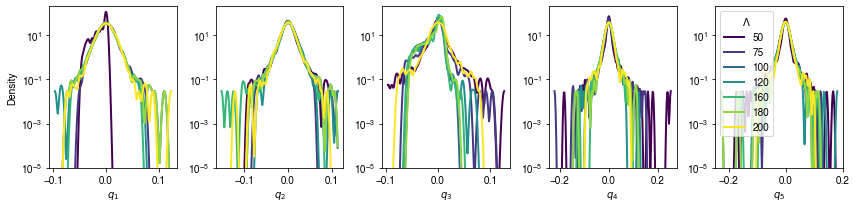

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kurtosis
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties

R_store = np.array(R_store)

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Create figure with 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
labels = [50,75, 100, 120, 160, 180,200]

print("\nKurtosis values for each distribution:")
print("=" * 60)
kurtosis_list=[]
for n in range(5):
    ax = axes[n]
    
    all_vals = np.concatenate(R_store[:, n, :])
    x_vals = np.linspace(np.min(all_vals), np.max(all_vals), 200)
    
    cmap = cm.get_cmap('viridis', len(R_store[:, n, :]))
    
    print(f"\nMode q_{n+1}:")

    kurtosis_mode=[]
    for i, R_f in enumerate(R_store[:, n, :]):
        kde = gaussian_kde(R_f)
        y = kde(x_vals)
        ax.plot(x_vals, y, color=cmap(i), label=labels[i], linewidth=2)
        
        # Calculate and print kurtosis
        kurt = kurtosis(R_f, fisher=True)  # fisher=True gives excess kurtosis
        if i>0:
            print(f"  Λ={labels[i]:3d}: kurtosis = {kurt:8.4f}")
            kurtosis_mode.append(Energy_store[i,n,n]*kurt)
    kurtosis_list.append(kurtosis_mode)

    ax.set_xlabel(f'$q_{{{n+1}}}$', fontproperties=helvetica)
    if n == 0:
        ax.set_ylabel('Density', fontproperties=helvetica)
    ax.set_yscale('log')
    ax.set_ylim([0.00001, 200])
    
    # Only show legend on the last subplot
    if n == 4:
        ax.legend(title=r'$\Lambda$', prop=helvetica, fontsize=8)
    
    # Apply Helvetica to tick labels
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

print("=" * 60)
plt.tight_layout()
plt.savefig("mode_hist/modes_all_subplots.png", bbox_inches='tight', dpi=500)
plt.show()

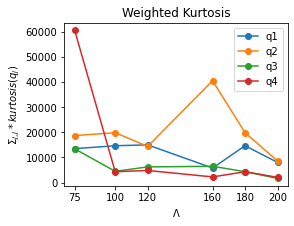

In [58]:
labels = [75, 100, 120, 160, 180, 200]
Energy_store=np.array(Energy_store)
plt.figure(figsize=(4, 3))
for i in range(4):
    kurtosis = kurtosis_list[i]
    plt.plot(labels, kurtosis, marker='o', label=f'q{i+1}')
plt.xticks(labels)
plt.xlabel('$\Lambda$')
plt.ylabel('$\Sigma_{j,j}*kurtosis(q_j)$')
plt.title('Weighted Kurtosis')
plt.legend()
plt.savefig("mode_hist/weighted_kurtosis_modes.png", bbox_inches='tight', dpi=500)
plt.show()

In [37]:
Energy_store=np.array(Energy_store)
print(Energy_store.shape)
print(Energy_store[0][1,1])

(7, 10, 10)
2328.1082254951325


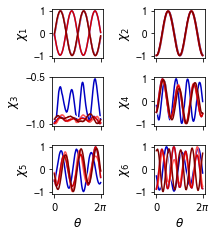

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties

R_store = np.array(R_store)

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()
X_store = np.array(X_store)

labels = [50,75, 100, 120, 160,180, 200]

# Create subplots: 3 rows, 2 columns (6 modes)
fig, axes = plt.subplots(3, 2, figsize=(3.1, 3.4))
fig.subplots_adjust(hspace=0.6, wspace=0.3)

# Create colormap for different lambda values
colors = cm.get_cmap('seismic')(np.linspace(0, 1, len(labels)))

for n in range(6):
    # Convert linear index to 2D indices for 3 rows, 2 columns
    row = n // 2
    col = n % 2
    ax = axes[row, col]
    
    # Plot each lambda value with different color
    for ST in range(len(labels)):
        Xi = X_store[ST, :, n]
        # Normalize each mode
        Xi_norm = Xi / np.max(np.abs(Xi))
        if ST>0:
            ax.plot(Xi_norm, label=f'Λ={labels[ST]}', color=colors[ST], linewidth=1.5)
    
    # Set labels with Helvetica font
    ax.set_ylabel(f'$\\chi_{{{n+1}}}$', fontproperties=helvetica, fontsize=12)
    
    # Only show legend on first subplot (top-left)
    #if n == 0:
    #    ax.legend(prop=helvetica, fontsize=8, loc='best')
    
    # Show x-label on bottom row
    if row == 2:
        ax.set_xlabel(r'$\theta$', fontproperties=helvetica, fontsize=12)
        # Set custom x-ticks
        ax.set_xticks([0, len(Xi) - 1])
        ax.set_xticklabels([r'$0$', r'$2\pi$'], fontproperties=helvetica)
    else:
        ax.set_xticks([0, len(Xi) - 1])
        ax.set_xticklabels([])
    
    # Apply Helvetica to tick labels
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    #ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mode_hist/spatial_modes_all.png", bbox_inches='tight', dpi=500)
plt.show()

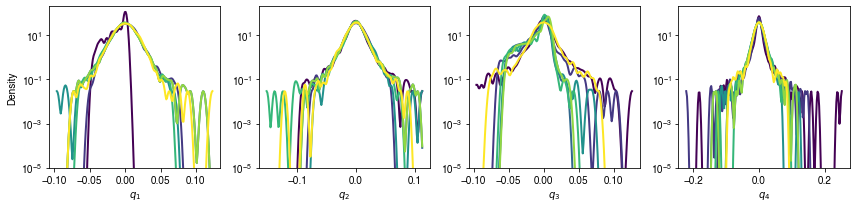

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties

R_store = np.array(R_store)

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Create figure with 5 subplots
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
labels = [50,75, 100, 120, 160,180,200]

for n in range(4):
    ax = axes[n]
    
    all_vals = np.concatenate(R_store[:, n, :])
    x_vals = np.linspace(np.min(all_vals), np.max(all_vals), 200)
    
    cmap = cm.get_cmap('viridis', len(R_store[:, n, :]))
    
    for i, R_f in enumerate(R_store[:, n, :]):
        kde = gaussian_kde(R_f)
        y = kde(x_vals)
        ax.plot(x_vals, y, color=cmap(i), label=labels[i], linewidth=2)
    
    ax.set_xlabel(f'$q_{{{n+1}}}$', fontproperties=helvetica)
    if n == 0:
        ax.set_ylabel('Density', fontproperties=helvetica)
    ax.set_yscale('log')
    ax.set_ylim([0.00001, 200])
    
    # Only show legend on the last subplot
    if n == 4:
        ax.legend(title=r'$\Lambda$', prop=helvetica, fontsize=8)
    
    # Apply Helvetica to tick labels
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig("mode_hist/modes_all_subplots.png", bbox_inches='tight', dpi=500)
plt.show()

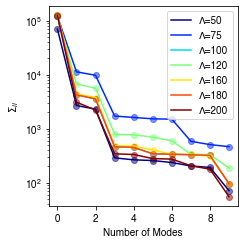

In [72]:
import matplotlib.cm as cm

plt.figure(figsize=(3.5, 3.5))

# Create colormap for different labels
colors = cm.get_cmap('jet')(np.linspace(0, 1, len(labels)))
labels = [50,75, 100, 120, 160,180,200]
for n in range(len(Energy_store)):
    Sr = np.diag(Energy_store[n])
    modes = np.arange(0, len(Sr), 1)
    
    # Use indexed color from the colormap
    plt.scatter(modes, Sr, alpha=0.5, color=colors[n])
    plt.plot(modes, Sr, alpha=1, color=colors[n],label=f'Λ={labels[n]}')
    
plt.ylabel(r'$\Sigma_{ii}$', fontproperties=helvetica)
plt.xlabel('Number of Modes', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.legend(prop=helvetica, fontsize=8)
plt.yscale('log')
plt.tight_layout()
plt.savefig('mode_hist/Energies_all.png', dpi=500, bbox_inches='tight')
plt.show()

In [21]:
def find_modes_all(normalized_h_store,ti,tf,n_sim):
    
    dt=2e-4
    
    
    Tf_units=tf*dt
    Ti_units=ti*dt
        
    u=np.array(normalized_h_store).T[:,ti:tf]
    t=np.arange(Ti_units,Tf_units,dt)
    print("lent",len(t))
    
    tot_t_len=len(u[0])
    
    U, S,Vt = np.linalg.svd(u)
    #ip=inner_product(u,thetas)
    #modes,feature_names, S2, Vh=vector_POD(ip,t,4)
    
    
    
    ri = 3
    Ur = U[:, :ri]
    Sr = np.diag(S[:ri])
    modes= Vt[:ri, :]
    
    
    Ur1 = U[:, 0:ri]
    Sr1 = np.diag(S[0:ri])
    modes1= Vt[0:ri, :]
    h_sub_1 = np.dot(Ur1, np.dot(Sr1, modes1))
    
    
   
    
    
    return modes,h_sub_1,S

h_list=[]


for files in [50,75,85,120,160,140,180,200]: 
    h_sub=np.loadtxt(f'hs_{files}.txt')
    h_list.append(h_sub)
#h_list.append(h_sub)


In [22]:
n_mode=1
lam_list = ["75","85","100","120", "140","160", "180","200"]
gamma_list=[]
S_list=[]
mean=[]
for lam in range(0,8):
    cop1, h_sub1, S1 = find_modes_all(h_list[lam], ti, 3000, n_mode)
    S_list.append(S1)
    





lent 3000
lent 3000
lent 3000
lent 3000
lent 3000
lent 3000
lent 3000
lent 3000


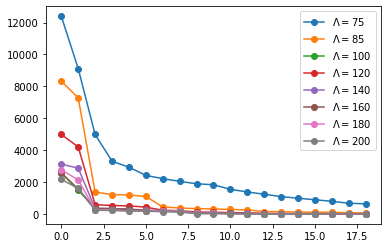

In [32]:
for lam in range(0,8):
    plt.plot(S_list[lam][1:20],"-o",label=f"$\Lambda={lam_list[lam]}$")
    np.savetxt(f'lang_reg_data6/S_{lam_list[lam]}.txt',S_list[lam][1:])
plt.legend()
#plt.savefig("mode_hist/energies.png")

In [39]:
print(np.array(S_list[:][1:10]))

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

In [36]:
np.savez('POD_lam_data.npz',S_list=S_list[:][1:20],lam_list=lam_list)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

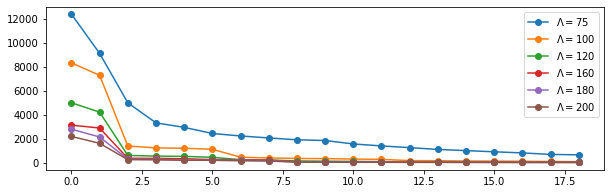

In [94]:
S_list=np.load('POD_lam_data.npz',allow_pickle=True)['S_list']
lam_list=np.load('POD_lam_data.npz',allow_pickle=True)['lam_list']
plt.figure(figsize=(10, 3))

for lam in range(0,6):
    plt.plot(S_list[lam][1:20],"-o",label=f"$\Lambda={lam_list[lam]}$")
    np.savetxt(f'lang_reg_data6/S_{lam_list[lam]}.txt',S_list[lam][1:])
plt.legend()
plt.savefig("mode_hist/energies.png")


Statistics for Γ distributions:
Λ= 75: mean = 0.015919, variance = 0.000760, skewness =   5.8919, kurtosis =  46.9548
Λ= 85: mean = 0.002757, variance = 0.000011, skewness =   3.3045, kurtosis =  16.9444
Λ=100: mean = 0.004091, variance = 0.000021, skewness =   2.7893, kurtosis =  13.0002
Λ=120: mean = 0.001545, variance = 0.000003, skewness =   2.9617, kurtosis =  12.4051
Λ=140: mean = 0.002752, variance = 0.000011, skewness =   3.3137, kurtosis =  17.0583
Λ=160: mean = 0.002027, variance = 0.000006, skewness =   3.6561, kurtosis =  21.3554
Λ=180: mean = 0.001547, variance = 0.000003, skewness =   2.9658, kurtosis =  12.4523
Λ=200: mean = 0.000794, variance = 0.000001, skewness =   2.1889, kurtosis =   5.3433


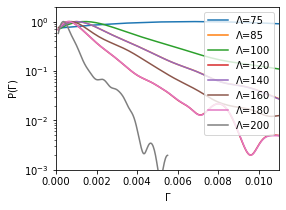

In [2]:
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi,150)
    offset= Q_sim[:,0] - Q_real[:,0]
    
    
    for i in range(0, 1000):
        sim_plot = Q_sim[:,i]
        real_plot = Q_real[:,i]
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        h_real = np.abs(np.trapz(real_plot, thetas))
        h_sim = np.abs(np.trapz(sim_plot, thetas))
        perimeter0_data.append(h_real)
        perimeter0_predict.append(h_sim)
        
    #plt.plot(perimeter_data)
    #plt.plot(perimeter0_data)
    
    gam_original = (np.array(perimeter_data)/np.array(perimeter0_data))-1
    gam_predict = (np.array(perimeter_predict)/np.array(perimeter0_predict))-1

    
    gam_original=gam_original
    gam_predict = gam_predict
    return gam_original, gam_predict

print("\nStatistics for Γ distributions:")
print("=" * 80)
    
plt.figure(figsize=(4, 3))
mean=[]
variance=[]
skewness_list=[]
kurtosis_list=[]
for files in [75,85,100,120,140,160,180,200]: 
    #h_sub=np.loadtxt(f'hs_{files}.txt')
    h_sub=np.loadtxt(f'h_test/h_{files}.txt')
    theta = np.linspace(0, 2 * np.pi, len(h_sub[0]), endpoint=False)

    dt=2e-4
    g1,g2=calc_deformation(h_sub.T+200, h_sub.T+200)

    # Calculate statistics
    g1_mean = np.mean(g1)
    g1_var = np.var(g1)
    g1_skewness = skew(g1)
    g1_kurt = kurtosis(g1, fisher=True)
    mean.append(g1_mean)
    variance.append(g1_var)
    skewness_list.append(g1_skewness)
    kurtosis_list.append(g1_kurt)
    
    print(f"Λ={files:3d}: mean = {g1_mean:8.6f}, variance = {g1_var:8.6f}, skewness = {g1_skewness:8.4f}, kurtosis = {g1_kurt:8.4f}")

    
    # Calculate KDE
    g1_kde=gaussian_kde(g1)
    x_vals = np.linspace(np.min(g1), np.max(g1), 200)
    y_vals = g1_kde(x_vals)
    
    # Normalize KDE to have max value of 1
    y_vals_norm = y_vals / np.max(y_vals)
    
    # Plot normalized KDE
    plt.plot(x_vals, y_vals_norm, label=f'Λ={files}')

print("=" * 80)

plt.yscale('log')
plt.xlabel('$\\Gamma$')
plt.ylabel('P($\\Gamma$)')
plt.ylim([0.001, 2])  # Adjusted for normalized values [0, 1]
plt.xlim([-0.00001, 0.011])
plt.legend()
plt.savefig("mode_hist/gamma_kde_normalized.png", bbox_inches='tight', dpi=500)
plt.show()

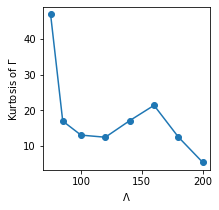

In [3]:
plt.figure(figsize=(3, 3))
plt.plot([75,85,100,120,140,160,180,200],kurtosis_list,"-o")
plt.xlabel('$\Lambda$')
plt.ylabel('Kurtosis of $\\Gamma$')
plt.savefig("mode_hist/gamma_kurtosis.png", bbox_inches='tight', dpi=400)

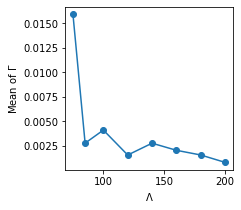

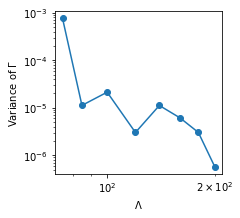

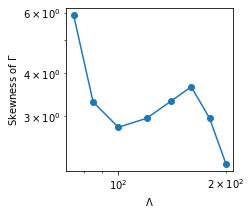

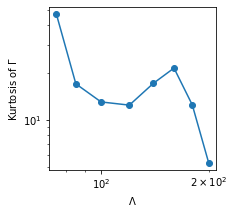

In [9]:
plt.figure(figsize=(3, 3))
plt.plot(np.array([75,85,100,120,140,160,180,200]),mean,"-o")
plt.xlabel('$\Lambda$')
plt.ylabel('Mean of $\\Gamma$')
#plt.yscale('log')
plt.savefig("mode_hist/gamma_mean.png", bbox_inches='tight', dpi=400)

plt.figure(figsize=(3, 3))
plt.plot(np.array([75,85,100,120,140,160,180,200]),variance,"-o")
plt.xlabel('$\Lambda$')
plt.ylabel('Variance of $\\Gamma$')
plt.yscale('log')
plt.xscale('log')
plt.savefig("mode_hist/gamma_variance.png", bbox_inches='tight', dpi=400)


plt.figure(figsize=(3, 3))
plt.plot(np.array([75,85,100,120,140,160,180,200]),skewness_list,"-o")
plt.xlabel('$\Lambda$')
plt.ylabel('Skewness of $\\Gamma$')
plt.yscale('log')
plt.xscale('log')
plt.savefig("mode_hist/gamma_skewness.png", bbox_inches='tight', dpi=400)

plt.figure(figsize=(3, 3))
plt.plot(np.array([75,85,100,120,140,160,180,200]),kurtosis_list,"-o")
plt.xlabel('$\Lambda$')
plt.ylabel('Kurtosis of $\\Gamma$')
plt.yscale('log')
plt.xscale('log')
plt.savefig("mode_hist/gamma_kurtosis.png", bbox_inches='tight', dpi=400)
np.savetxt('mode_hist/var_stats.txt',variance)
np.savetxt('mode_hist/mean_stats.txt',mean)
np.savetxt('mode_hist/kurtosis_stats.txt',kurtosis_list)


In [ ]:
data=np.loadtxt("mode_hist/gamma_stats.txt", skiprows=1)
Lambda=data[:,0]
mean=data[:,1]
variance=data[:,2]
skewness_list=data[:,3]
kurtosis_list=data[:,4]

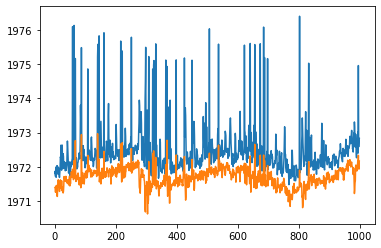

In [131]:
from matplotlib import pyplot as plt
import numpy as np
h=np.loadtxt('h_files/h2_200.txt')  

def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi, 200)
    offset = Q_sim[:, 0] - Q_real[:, 0]
    
    for i in range(0, 1000):
        sim_plot = Q_sim[:, i]
        real_plot = Q_real[:, i]
        
        # Calculate actual perimeters
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        # Calculate areas using trapezoidal integration in polar coordinates
        # Area = 0.5 * integral(r^2 * dθ)
        area_real = 0.5 * np.trapz(real_plot**2, thetas)
        area_sim = 0.5 * np.trapz(sim_plot**2, thetas)
        
        # Calculate perimeter of equivalent circle with same area
        # For a circle: A = πr² → r = sqrt(A/π)
        # Perimeter = 2πr = 2π*sqrt(A/π) = 2*sqrt(πA)
        perimeter0_real = 2 * np.sqrt(np.pi * area_real)
        perimeter0_sim = 2 * np.sqrt(np.pi * area_sim)
        
        perimeter0_data.append(perimeter0_real)
        perimeter0_predict.append(perimeter0_sim)
    plt.plot(perimeter_data)
    plt.plot(perimeter0_data)
    # Calculate deformation parameter Γ = (P/P₀) - 1
    gam_original = (np.array(perimeter_data) / np.array(perimeter0_data)) - 1
    gam_predict = (np.array(perimeter_predict) / np.array(perimeter0_predict)) - 1
    
    return gam_original, gam_predict


gam1,gam2=calc_deformation(h+200, h+200)


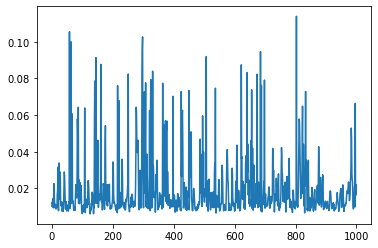

In [134]:
plt.plot(50*gam1)

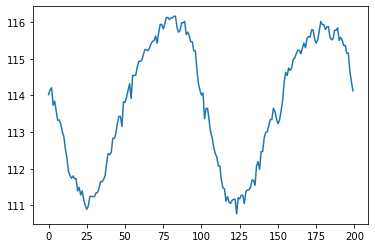

In [125]:
plt.plot(h[:,0])